## Canal de Comunicação
 
 O canal de comunicação é o meio pelo qual o sinal será transmitido do transmissor ao receptor. Esse meio pode ser um cabo, uma fibra óptica ou mesmo o ar, e em cada um deles ocorrem efeitos físicos que afetam o sinal sendo transmitido, sendo assim, no receptor chega uma versão corrompida do sinal transmitido. Nesse capítulo vamos analisar alguns desses efeitos.
 
## Canal com ruído Gaussiano Branco
 
 Qualquer condutor com temperatura diferente do zero absoluto produz ruído térmico devido à agitação dos elétrons presentes em sua composição. O movimento dessas cargas elétricas cria pequenos campos elétricos, cuja interferência gera uma tensão elétrica que pode ser medida nos terminais do condutor. O Teorema central do limite diz que para uma variável aleatória de distribuição qualquer, a média de uma amostra tende a uma distribuição normal, quando o espaço amostral se aproxima do infinito, logo essa tensão gerada pela contribuição infinitesimal dos elétrons pode ser modelada como um processo Gaussiano.
 
 Um canal com ruído aditivo Gaussiano branco é um canal cujo único efeito é a adição de um ruído modelado como um processo Gaussiano ao sinal. A expressão matemática para um canal AWGN é
 $$
 r(t) = s(t) + n(t).
 $$
sendo $s(t)$ o sinal transmitido, e $n(t)$ uma amostra de um processo Gaussiano com média zero e densidade espectral de potência $\frac{N_0}{2}$ 

Normalmente modela-se o ruído como uma variável aleatória com distribuição Gaussiana com média zero e variância $\sigma^2$, ou seja $n(t) \sim \mathcal{N}(0, \sigma^2)$. 

Um variável aleatória $X$ Gaussiana tem densidade de probabilidade:
$$F_x(X) = \frac{1}{\sqrt{2\pi\sigma^2}}e^{-\frac{(x-\mu)^2}{2\sigma^2}}
$$
sendo $\mu$ a média e $\sigma^2$ a variância de $X$.

Dado um sistema $h(t)$ cuja entrada é um sinal $x(t)$ com Densidade Espectral de Potência 
$$
S_{X}(f) = \int_{-\infty}^{\infty}R_{XX}(\tau)e^{-j2\pi f\tau}d\tau,$$ a saída desse sistema $y(t)$ tem densidade espectral
$$
S_Y(f) = |H(f)|^2 S_x(f).
$$

Ver simulação ruido.grc para visualizar o sinal ruído no  tempo e o histograma da distruição das amplitudes.

O sinal recebido é uma versão distorcida do sinal enviado, e esse fato pode ser visualizado no diagrama de constelação do sinal recebido. Na simulação psk.grc é possível visualizar a modificação da constelação a medida que a variância do ruído aumenta.

Um dos parâmetros para análise de desempenho dos sistemas de comunicação é a relação entre a potência do sinal transmitido e a potência do ruído, denominada de **relação sinal-ruído** (SNR, do inglês *signal to noise ratio*). Normalmente expressa em dB, tem-se
$$
SBR_{dB} = 10\log_{10} \frac{P_s}{P_N}.
$$
 
 O rúdio aditivo Gaussino Branco tem potência igual a variância $\sigma^2$ da distribuição Gaussiana que o descreve. Numa simulação computacional, normalmente esse valor é derivado da relação (ou razão) sinal-ruído (SNR - *Signal to Noise Ratio*), que consiste da razão entre a potência do sinal $P_s$ e a potência do ruído, e que normalmente é dada em dB, ou seja,
$$ SNR_{dB} = 10\log_{10}\left(\frac{P_s}{P_n}\right) = 10\log_{10}\left(\frac{P_s}{\sigma^2}\right).$$

Assim dado $P_s$, na simulação devemos gerar amostras de uma variável aleatória Gaussiana com variância $\sigma^2$. Uma prática comum é considerar que o sinal tem potência unitária, $P_s = 1$, calcular
$$ \sigma^2 = 10^{-SNR_{dB}/10}.$$

## Efeito do ruído em banda básica

Neste caso não há demodulador, e o receptor consiste de um filtro passa-baixas de largura W. Assim, a potência do ruído é
$$ P_n = \int_{-W}^{W}\frac{N_0}{2}df = N_0 W$$
e a relação sinal-ruído para uma potência recebida $P_R$
$$ \left(\frac{S}{N}\right)_b = \frac{P_R}{N_0 W}.$$

Potência do sinal Ps = 1.0000
SNR em dB = 10 dB
SNR linear = 10.0000
Potência do ruído Pn = 0.1000
Variância do ruído sigma² = 0.1000
Desvio padrão do ruído sigma = 0.3162


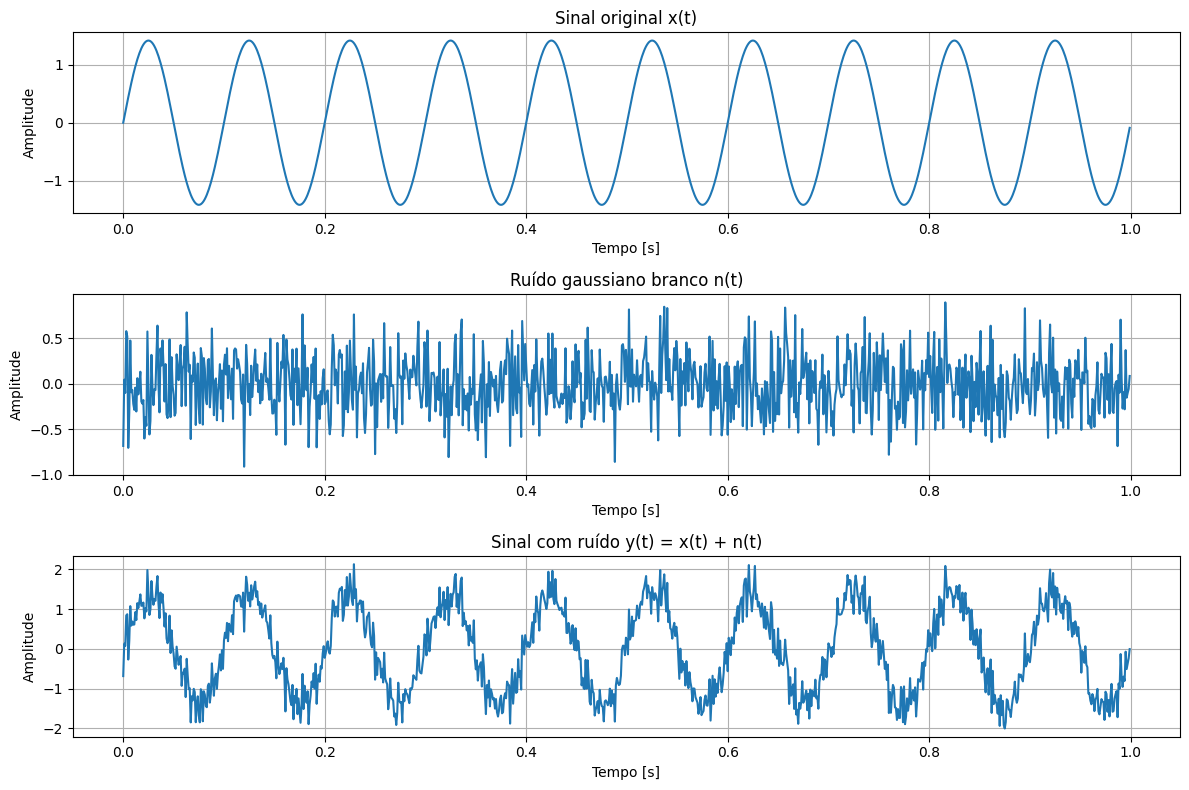

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ============================
# Parâmetros do sinal
# ============================

fs = 1000          # Frequência de amostragem em Hz
T = 1              # Duração do sinal em segundos
f0 = 10            # Frequência do sinal senoidal em Hz
A = np.sqrt(2)              # Amplitude do sinal. O valor 2, é para que P_s = A^2/2 = 1.

t = np.arange(0, T, 1/fs)

# Sinal original
x = A * np.sin(2 * np.pi * f0 * t)

# ============================
# Potência do sinal
# ============================

Ps = np.mean(x**2)

# ============================
# Relação sinal-ruído
# ============================

SNR_dB = 10

SNR_linear = 10**(SNR_dB/10)

# Como SNR = Ps / Pn
# então Pn = Ps / SNR
Pn = Ps / SNR_linear

# Para ruído gaussiano branco:
# potência do ruído = variância do ruído
sigma2 = Pn
sigma = np.sqrt(sigma2)

# ============================
# Ruído gaussiano branco
# ============================

n = sigma * np.random.randn(len(t))

# Sinal recebido
y = x + n

# ============================
# Resultados
# ============================

print(f"Potência do sinal Ps = {Ps:.4f}")
print(f"SNR em dB = {SNR_dB} dB")
print(f"SNR linear = {SNR_linear:.4f}")
print(f"Potência do ruído Pn = {Pn:.4f}")
print(f"Variância do ruído sigma² = {sigma2:.4f}")
print(f"Desvio padrão do ruído sigma = {sigma:.4f}")

# ============================
# Gráficos
# ============================

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t, x)
plt.title("Sinal original x(t)")
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t, n)
plt.title("Ruído gaussiano branco n(t)")
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t, y)
plt.title("Sinal com ruído y(t) = x(t) + n(t)")
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

### Ruído na Modulação AM

Potência do sinal: 1.3200
SNR(dB): 5
Variância do ruído: 0.4174


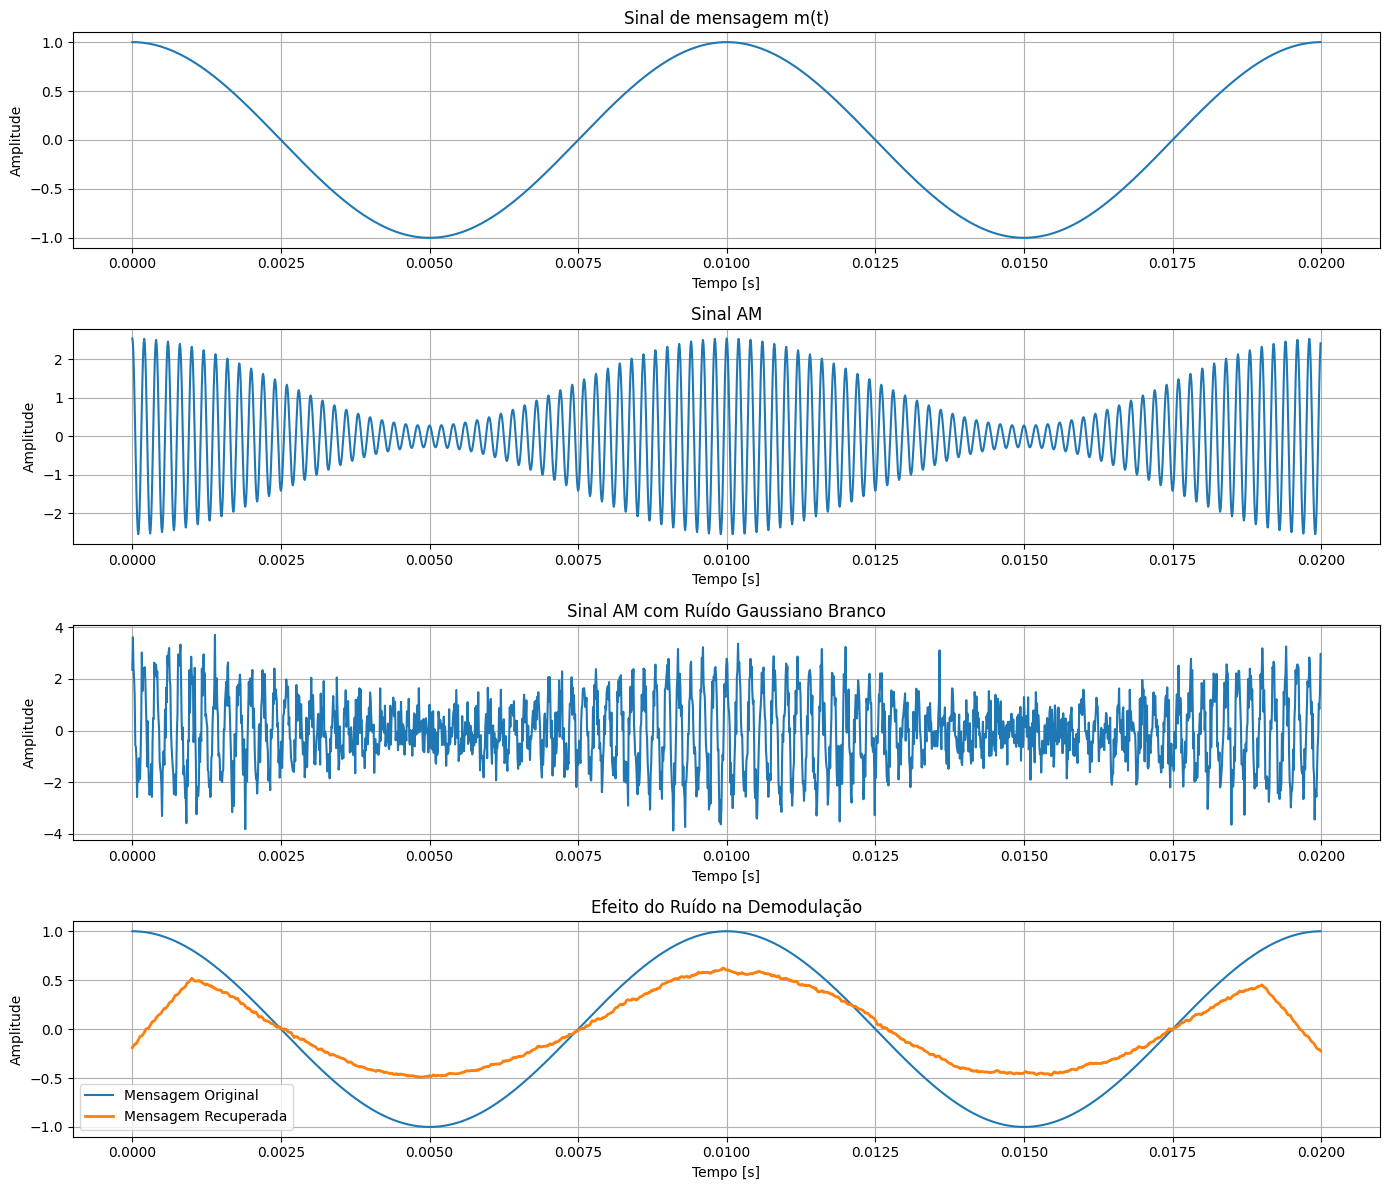

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARÂMETROS
# =====================================================

fs = 100000              # frequência de amostragem
T = 0.02                 # duração do sinal
t = np.arange(0, T, 1/fs)

# Sinal de mensagem
fm = 100                 # frequência da mensagem
Am = 1                   # amplitude da mensagem

m_t = Am * np.cos(2*np.pi*fm*t)

# Portadora
fc = 5000                # frequência da portadora
Ac = np.sqrt(2)                   # amplitude da portadora

c_t = Ac * np.cos(2*np.pi*fc*t)

# Índice de modulação
mu = 0.8

# =====================================================
# Modulação AM
# s(t) = Ac [1 + mu*m(t)] cos(2*pi*fc*t)
# =====================================================

s_t = Ac * (1 + mu*m_t) * np.cos(2*np.pi*fc*t)

# =====================================================
# Potência do sinal
# =====================================================

Ps = np.mean(s_t**2)

# =====================================================
# RELAÇÃO SINAL-RUÍDO
# =====================================================

SNR_dB = 5

SNR_linear = 10**(SNR_dB/10)

# potência do ruído
Pn = Ps / SNR_linear

# variância do ruído
sigma2 = Pn
sigma = np.sqrt(sigma2)

# =====================================================
# RUÍDO GAUSSIANO BRANCO
# =====================================================

n_t = sigma * np.random.randn(len(t))

# sinal recebido
r_t = s_t + n_t

# =====================================================
# DEMODULAÇÃO POR DETECTOR DE ENVOLTÓRIA
# =====================================================

envelope = np.abs(r_t)

# filtro passa-baixa simples
N = 200
h = np.ones(N)/N

m_rec = np.convolve(envelope, h, mode='same')

# =====================================================
# RESULTADOS
# =====================================================

print(f"Potência do sinal: {Ps:.4f}")
print(f"SNR(dB): {SNR_dB}")
print(f"Variância do ruído: {sigma2:.4f}")

# =====================================================
# GRÁFICOS
# =====================================================

plt.figure(figsize=(14, 12))

# mensagem
plt.subplot(4,1,1)
plt.plot(t, m_t)
plt.title("Sinal de mensagem m(t)")
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.grid(True)

# AM sem ruído
plt.subplot(4,1,2)
plt.plot(t, s_t)
plt.title("Sinal AM")
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.grid(True)

# AM com ruído
plt.subplot(4,1,3)
plt.plot(t, r_t)
plt.title("Sinal AM com Ruído Gaussiano Branco")
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.grid(True)

# recuperação
plt.subplot(4,1,4)
plt.plot(t, m_t, label='Mensagem Original')
plt.plot(t, m_rec - np.mean(m_rec),
         label='Mensagem Recuperada',
         linewidth=2)

plt.title("Efeito do Ruído na Demodulação")
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Potência do sinal AM Ps = 1.3200
SNR = 5 dB
Variância do ruído sigma² = 0.4174
Desvio padrão do ruído sigma = 0.6461


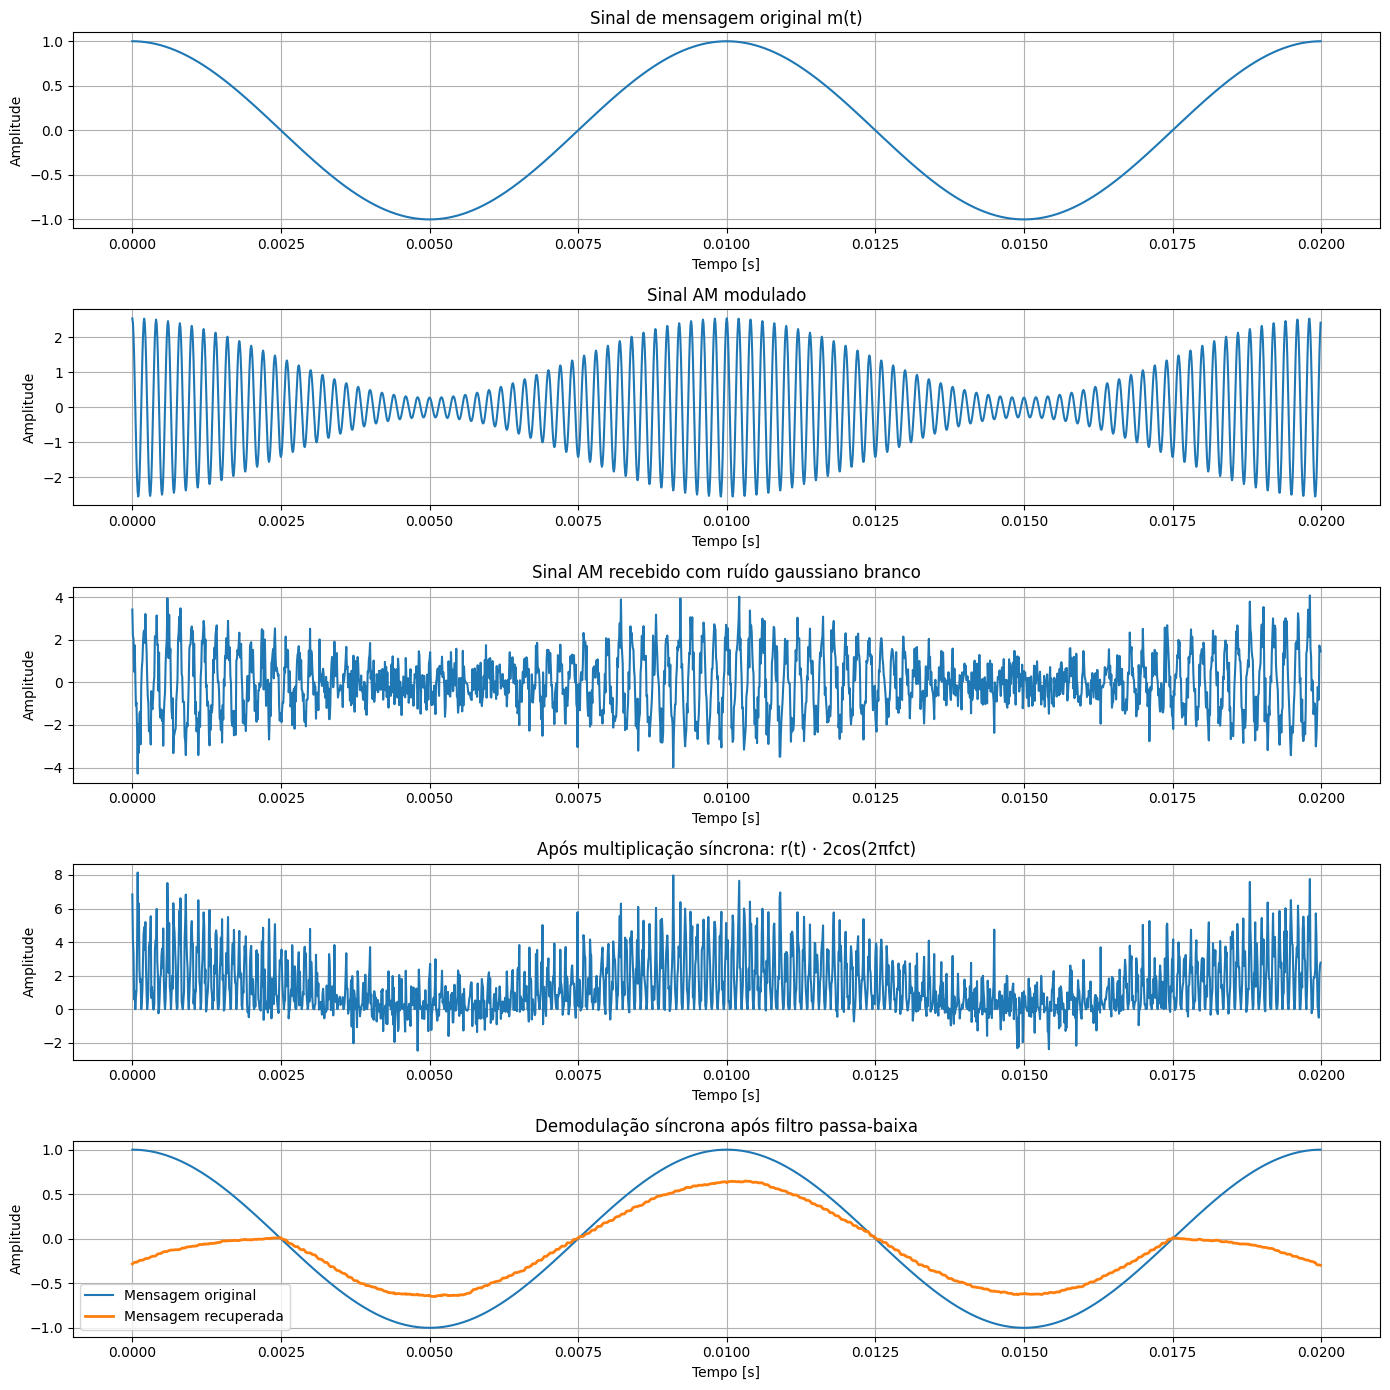

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# PARÂMETROS
# =====================================================

fs = 100000
T = 0.02
t = np.arange(0, T, 1/fs)

fm = 100
Am = 1
m_t = Am * np.cos(2*np.pi*fm*t)

fc = 5000
Ac = np.sqrt(2)
mu = 0.8

# =====================================================
# MODULAÇÃO AM DSB-LC
# s(t) = Ac [1 + mu*m(t)] cos(2*pi*fc*t)
# =====================================================

s_t = Ac * (1 + mu*m_t) * np.cos(2*np.pi*fc*t)

# =====================================================
# ADIÇÃO DE RUÍDO GAUSSIANO BRANCO
# =====================================================

Ps = np.mean(s_t**2)

SNR_dB = 5
SNR_linear = 10**(SNR_dB/10)

Pn = Ps / SNR_linear
sigma2 = Pn
sigma = np.sqrt(sigma2)

n_t = sigma * np.random.randn(len(t))
r_t = s_t + n_t

# =====================================================
# DEMODULAÇÃO SÍNCRONA
# =====================================================
# O receptor multiplica o sinal recebido por uma portadora local
# sincronizada em frequência e fase com a portadora do transmissor.

lo_t = 2 * np.cos(2*np.pi*fc*t)   # oscilador local

z_t = r_t * lo_t                  # produto síncrono

# Após a multiplicação, surgem:
# - uma componente em baixa frequência, proporcional à mensagem
# - uma componente em 2fc, que deve ser removida por filtro passa-baixa

# =====================================================
# FILTRO PASSA-BAIXA SIMPLES
# =====================================================

N = 500
h = np.ones(N) / N

z_lpf = np.convolve(z_t, h, mode='same')

# Remoção da componente DC da AM convencional
m_rec = (z_lpf / Ac - 1) / mu

# =====================================================
# RESULTADOS
# =====================================================

print(f"Potência do sinal AM Ps = {Ps:.4f}")
print(f"SNR = {SNR_dB} dB")
print(f"Variância do ruído sigma² = {sigma2:.4f}")
print(f"Desvio padrão do ruído sigma = {sigma:.4f}")

# =====================================================
# GRÁFICOS
# =====================================================

plt.figure(figsize=(14, 14))

plt.subplot(5, 1, 1)
plt.plot(t, m_t)
plt.title("Sinal de mensagem original m(t)")
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(5, 1, 2)
plt.plot(t, s_t)
plt.title("Sinal AM modulado")
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(5, 1, 3)
plt.plot(t, r_t)
plt.title("Sinal AM recebido com ruído gaussiano branco")
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(5, 1, 4)
plt.plot(t, z_t)
plt.title("Após multiplicação síncrona: r(t) · 2cos(2πfct)")
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(5, 1, 5)
plt.plot(t, m_t, label="Mensagem original")
plt.plot(t, m_rec, label="Mensagem recuperada", linewidth=2)
plt.title("Demodulação síncrona após filtro passa-baixa")
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Sinal Analítico

O sinal analítico é uma representação complexa de um sinal real que permite separar claramente informações de amplitude, fase e frequência instantânea.

Sendo $x(t)$ um sinal real, um sinal analítico é dado por
$$
x_a(t) = x(t) + jx_h(t)
$$
sendo $x_h(t)$ a transformada de hilbert de $x(t)$.

Obs.: Sendo $x(t) = \cos\omega_c t$, então $x_h(t) = sen\omega_c t$, e 
$$
x_a(t) = \cos\omega_c t + j sen\omega_c t = e^{j\omega_c t}$$
que só contém a exponencial positiva.


### Sinal AM

Considere um sinal AM convencional:
$$
s(t)=A_c\left[1+\mu m(t)\right]\cos(2\pi f_c t)
$$
o sinal analítico é dado por
$$
s_a(t)=A_c\left[1+\mu m(t)\right][\cos(2\pi f_c t) + j\sin(2\pi f_c t)] = A_c\left[1+\mu m(t)\right]e^{j2\pi f_c t}
$$
O módulo do sinal analítico é 
$$
|s_a(t)| = A_c\left[1+\mu m(t)\right].
$$

### Sinal FM
$$ s(t) = A_c\cos\left(\omega_c t + k_f\int_{0}^{t}m(\alpha)d\alpha\right)
$$
escrevendo
$$
s(t) = A_c \cos[\phi(t)]
$$
com $\phi(t) = \omega_c t + k_f\int_{0}^{t}m(\alpha)d\alpha$,
temos que
$$ s_a(t) = A_ce^{j\phi(t)}$$
de onde é possível obter $\phi(t)$, e usando a frequência instantânea
$$f_i = \frac{d\phi(t)}{dt} = \omega_c + k_fm(t).$$

### Sinal PM

Procedimento similar ao sinal FM, com a diferença que 
$$
f_i = \phi(t) = \omega_c + k_pm(t).
$$

Potência do sinal FM Ps = 1.0000
SNR = 10 dB
Variância do ruído sigma² = 0.1000
Desvio padrão do ruído sigma = 0.3162


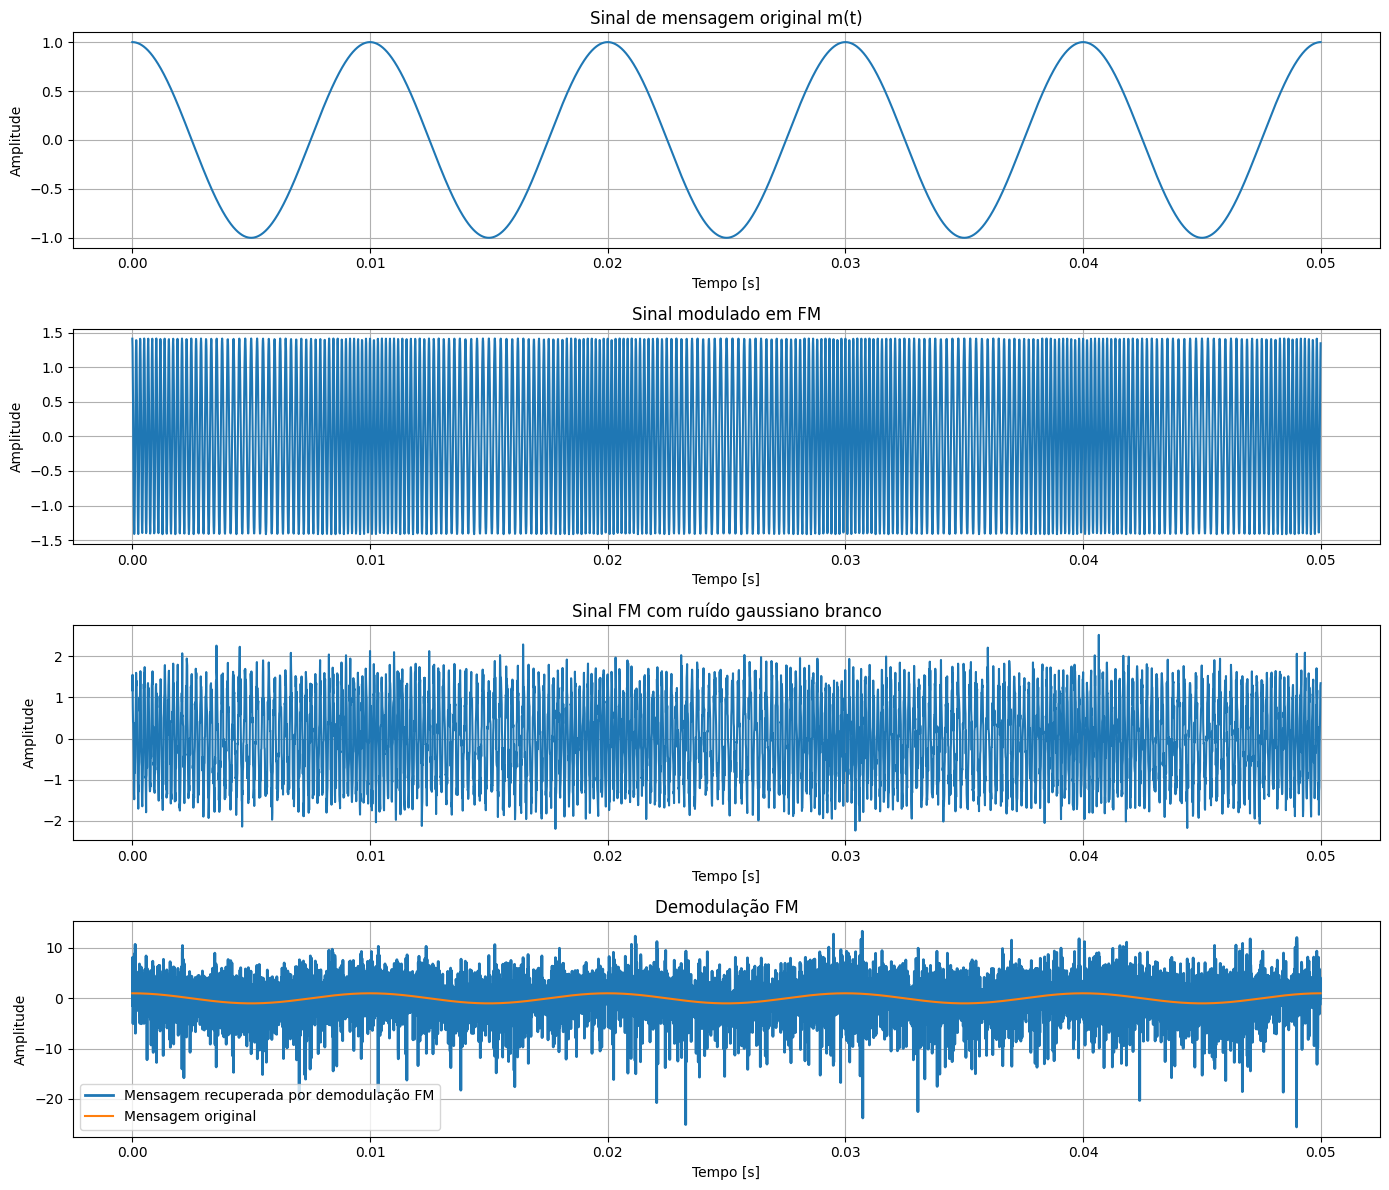

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# =====================================================
# PARÂMETROS
# =====================================================

fs = 100000          # frequência de amostragem [Hz]
T = 0.05             # duração [s]
t = np.arange(0, T, 1/fs)

# Mensagem
fm = 100             # frequência da mensagem [Hz]
Am = 1               # amplitude da mensagem
m_t = Am * np.cos(2*np.pi*fm*t)

# Portadora
fc = 5000            # frequência da portadora [Hz]
Ac = np.sqrt(2)               # amplitude da portadora

# Sensibilidade em frequência
kf = 1000            # Hz por unidade de amplitude

# =====================================================
# MODULAÇÃO FM
# s(t) = Ac cos(2πfc t + 2πkf ∫m(τ)dτ)
# =====================================================

integral_m = np.cumsum(m_t) / fs

s_t = Ac * np.cos(2*np.pi*fc*t + 2*np.pi*kf*integral_m)

# =====================================================
# ADIÇÃO DE RUÍDO GAUSSIANO BRANCO
# =====================================================

Ps = np.mean(s_t**2)

SNR_dB = 10
SNR_linear = 10**(SNR_dB/10)

Pn = Ps / SNR_linear
sigma2 = Pn
sigma = np.sqrt(sigma2)

n_t = sigma * np.random.randn(len(t))
r_t = s_t + n_t

# =====================================================
# DEMODULAÇÃO FM
# =====================================================
# Usa o sinal analítico para estimar a fase instantânea.
# Depois calcula a frequência instantânea.

analytic_signal = hilbert(r_t)

phase = np.unwrap(np.angle(analytic_signal))

instantaneous_frequency = np.diff(phase) * fs / (2*np.pi)

# Remove a frequência da portadora
m_rec = (instantaneous_frequency - fc) / kf

# Ajuste do vetor de tempo por causa da derivada
t_rec = t[1:]

# =====================================================
# RESULTADOS
# =====================================================

print(f"Potência do sinal FM Ps = {Ps:.4f}")
print(f"SNR = {SNR_dB} dB")
print(f"Variância do ruído sigma² = {sigma2:.4f}")
print(f"Desvio padrão do ruído sigma = {sigma:.4f}")

# =====================================================
# GRÁFICOS
# =====================================================

plt.figure(figsize=(14, 12))

plt.subplot(4, 1, 1)
plt.plot(t, m_t)
plt.title("Sinal de mensagem original m(t)")
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(t, s_t)
plt.title("Sinal modulado em FM")
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(t, r_t)
plt.title("Sinal FM com ruído gaussiano branco")
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(t_rec, m_rec, label="Mensagem recuperada por demodulação FM", linewidth=2)
plt.plot(t, m_t, label="Mensagem original")
plt.title("Demodulação FM")
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Potência do sinal PM Ps = 1.0000
SNR = 0 dB
Variância do ruído sigma² = 1.0000
Desvio padrão do ruído sigma = 1.0000


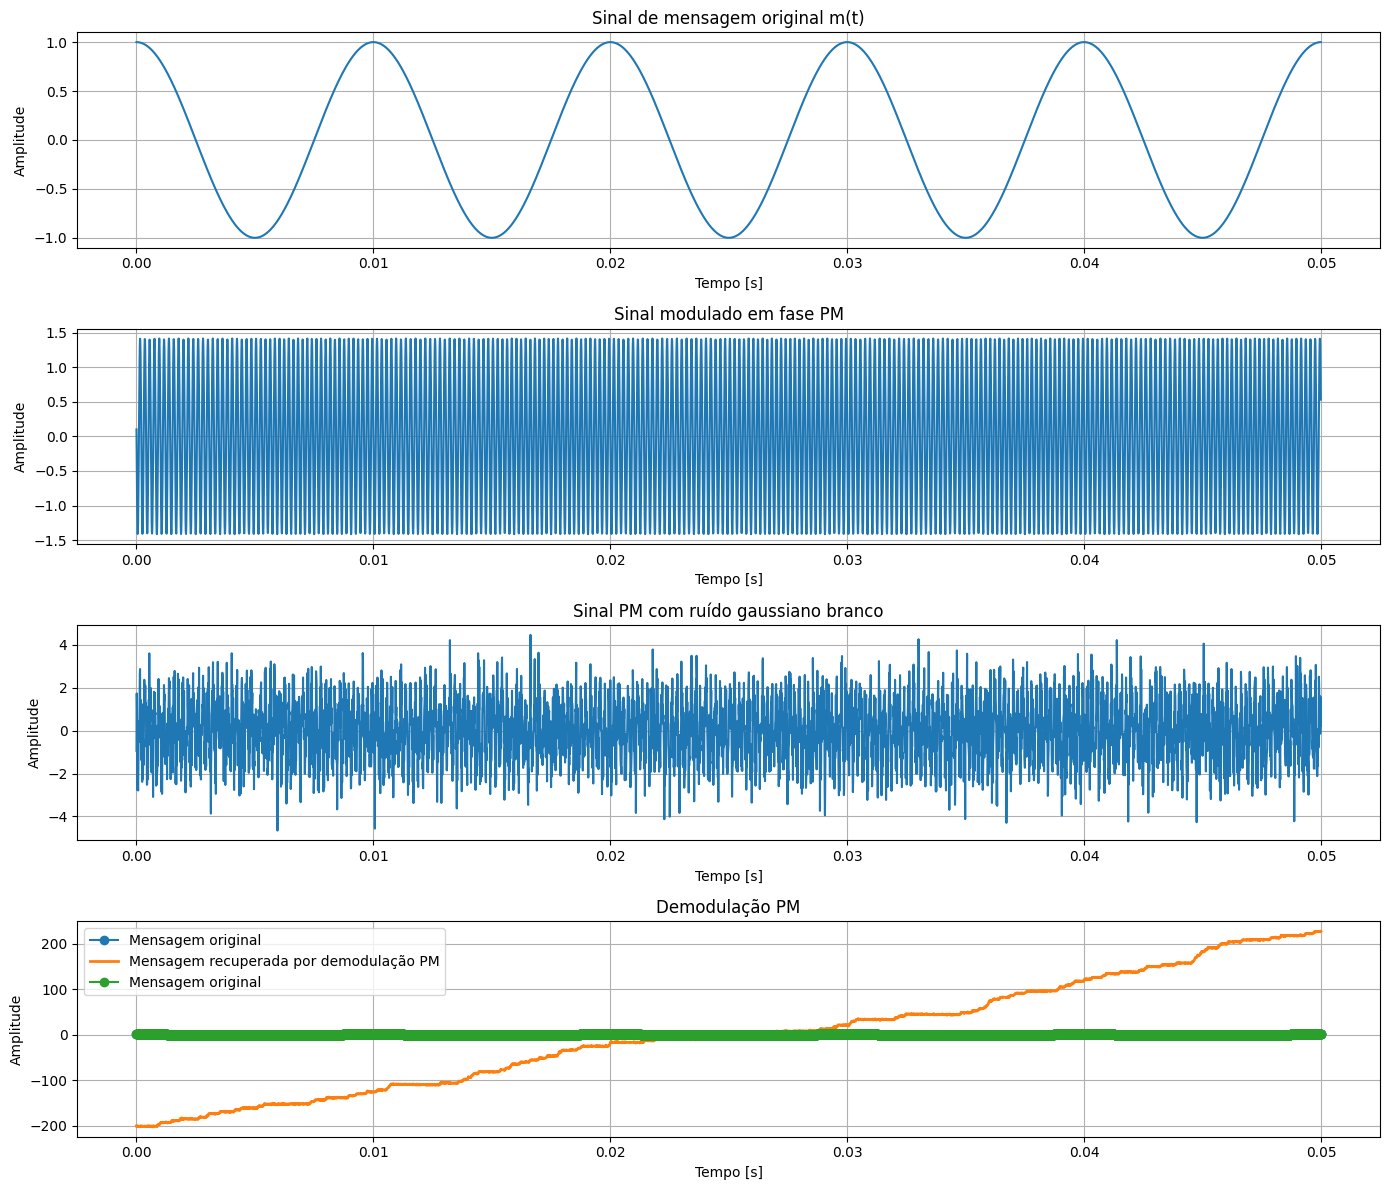

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# =====================================================
# PARÂMETROS
# =====================================================

fs = 100000          # frequência de amostragem [Hz]
T = 0.05             # duração [s]
t = np.arange(0, T, 1/fs)

# Mensagem
fm = 100             # frequência da mensagem [Hz]
Am = 1               # amplitude da mensagem
m_t = Am * np.cos(2*np.pi*fm*t)

# Portadora
fc = 5000            # frequência da portadora [Hz]
Ac = np.sqrt(2)               # amplitude da portadora

# Sensibilidade de fase
kp = 1.5             # radianos por unidade de amplitude

# =====================================================
# MODULAÇÃO PM
# s(t) = Ac cos(2πfc t + kp m(t))
# =====================================================

s_t = Ac * np.cos(2*np.pi*fc*t + kp*m_t)

# =====================================================
# ADIÇÃO DE RUÍDO GAUSSIANO BRANCO
# =====================================================

Ps = np.mean(s_t**2)

SNR_dB = 0
SNR_linear = 10**(SNR_dB/10)

Pn = Ps / SNR_linear
sigma2 = Pn
sigma = np.sqrt(sigma2)

n_t = sigma * np.random.randn(len(t))
r_t = s_t + n_t

# =====================================================
# DEMODULAÇÃO PM
# =====================================================
# Usa o sinal analítico para estimar a fase instantânea.
# A fase estimada contém:
# phi(t) = 2πfc t + kp m(t)
# Logo:
# m(t) = [phi(t) - 2πfc t] / kp

analytic_signal = hilbert(r_t)

phase = np.unwrap(np.angle(analytic_signal))

carrier_phase = 2*np.pi*fc*t

m_rec = (phase - carrier_phase) / kp

# Remoção de offset residual
m_rec = m_rec - np.mean(m_rec)

# =====================================================
# RESULTADOS
# =====================================================

print(f"Potência do sinal PM Ps = {Ps:.4f}")
print(f"SNR = {SNR_dB} dB")
print(f"Variância do ruído sigma² = {sigma2:.4f}")
print(f"Desvio padrão do ruído sigma = {sigma:.4f}")

# =====================================================
# GRÁFICOS
# =====================================================

plt.figure(figsize=(14, 12))

plt.subplot(4, 1, 1)
plt.plot(t, m_t)
plt.title("Sinal de mensagem original m(t)")
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(t, s_t)
plt.title("Sinal modulado em fase PM")
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(t, r_t)
plt.title("Sinal PM com ruído gaussiano branco")
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(t, m_t, label="Mensagem original",marker='o')
plt.plot(t, m_rec, label="Mensagem recuperada por demodulação PM", linewidth=2)
plt.plot(t, m_t, label="Mensagem original",marker='o')
plt.title("Demodulação PM")
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Figura de Ruído (*Noise Figure* – NF)

### Definição

É uma métrica utilizada para quantificar o quanto um sistema de comunicações degrada a qualidade de um sinal recebido devido ao ruído adicional introduzido pelos seus próprios componentes internos.

Ela mede a degradação da relação sinal-ruído (SNR) entre a entrada e a saída de um dispositivo ou receptor.

Considerando que a densidade espectral do ruído térmico é dada por
$$ n(f) = \frac{hf}{e^{\frac{hf}{kT} - 1}}$$
sendo:
- $k = 1,38\times 10^{-23}\ J/K$ a constante de Boltzman;
- $T$ temperatura em Kelvin;
- $h = 6,6254\times 10^{-34}\ J.s$ a constante de Planck;
que para $f$ muito menor que $kT/h$ ($f << 6250\ GHz$
$$n(f) = kT.$$

A DEP da ruído adicionado pelo receptor pode ser modelada por
$$\eta_R = (F -1)kT,$$ sendo $F \geq 1$ a figura de ruído.

Logo a DEP total do ruído é
$$\eta_e = kT + (F -1)kT = FkT.$$


> Exemplo:Considere:

SNR na entrada do receptor:

$$
SNR_{entrada}=20 \text{ dB}
$$

Figura de ruído do receptor:

$$
NF=5 \text{ dB}
$$
então:
$$
SNR_{saída}=20-5=15 \text{ dB}
$$

O receptor degradou a qualidade do sinal em 5 dB.



A figura de ruído afeta diretamente:
* sensibilidade do receptor
* alcance do enlace
* probabilidade de erro (BER)
* cobertura wireless
* modulações de alta ordem (QAM)

Em sistemas modernospequenos aumentos de NF podem inviabilizar a comunicação.


> Exemplo 1: Amplificador de Baixo Ruído (LNA)

> Considere um receptor de satélite: sinal recebido muito fraco potência próxima ao nível de ruído térmico

> Um LNA possui:
> - ganho alto: 20 dB
> - figura de ruído baixa: 0.8 dB

> Aplicação:
> - GPS
> - rádio astronomia
> - comunicação via satélite
> - 5G mmWave


> Exemplo 2: Considere um enlace sem fio:
> - sinal recebido: −95 dBm
> - largura de banda: 1 MHz
> - receptor projetado assumindo:
> - NF = 0 dB (ideal)

> O projetista calcula: $SNR \approx 19 dB$.


> Na implementação física:
> - LNA barato
> - cabos longos
> - mixer ruidoso

> Resultado $NF = 10\ dB$, logo SNR efetiva $\approx 9 dB.$

## Efeito Interferente do Ruído Térmico

O ruído térmico que se soma ao sinal recebido na entrada do receptor torna-se significativo quando a potência do sinal recebido é reduzida, o que normalmente ocorre em sistemas de comunicação reais.

O ruído térmico que interfere sobre uma portadora de frequência $f_0$, contido dentro de uma faixa de largura $B_R$ centrada em $f_0$, pode ser representado por:
$$
n(t)=n_c(t)\cos(2\pi f_0 t)+n_s(t)\sin(2\pi f_0 t)
\tag{7.25}
$$
sendo:
- $n_c(t)$ e $n_s(t)$ são componentes gaussianas em quadratura;
- ambas possuem média nula;
- ambas possuem valor eficaz $\sigma$.


### Potência Média do Ruído

Como $n_c(t)$ e $n_s(t)$ são independentes e gaussianos:
$$
\overline{n^2(t)}
=
\frac{1}{2}\overline{n_c^2(t)}
+
\frac{1}{2}\overline{n_s^2(t)}
=
\sigma^2
$$


#### Soma da Portadora com o Ruído

Somando-se à portadora:
$$
E_R\cos(2\pi f_0 t)
$$
o ruído produz:
- uma perturbação de amplitude;
- uma perturbação de fase.
A soma pode ser escrita como:
$$
E_R\cos(2\pi f_0 t)+n(t)
=
E(t)\cos\left[2\pi f_0 t+\alpha(t)\right]
\tag{7.27}
$$


A amplitude instantânea resultante é:
$$
E(t)
=
E_R
\sqrt{
1+
\frac{2n_c(t)}{E_R}
+
\frac{n_c^2(t)+n_s^2(t)}{E_R^2}
}
\tag{7.27a}
$$

A perturbação angular é dada por:
$$
\alpha(t)
=
-\tan^{-1}
\left[
\frac{n_s(t)}
{E_R+n_c(t)}
\right]
$$


Quando:
$$
E_R \gg \sigma
$$

podemos utilizar aproximações lineares.
$$
E(t)
\cong
E_R
\left[
1+\frac{n_c(t)}{E_R}
\right]
\tag{7.27c}
$$

$$
\alpha(t)
\cong
-\frac{n_s(t)}{E_R}
\tag{7.27d}
$$


Como $n_c(t)$ e $n_s(t)$ são tensões gaussianas em quadratura, a soma do ruído térmico com a portadora produz um fasor resultante cuja extremidade fica distribuída dentro de uma “nuvem” probabilística.

![Efeito_Ruído térmico](Figuras/Ruido_Modulacao.png)

A extremidade do vetor da portadora fica distribuída estatisticamente ao redor do valor ideal devido ao ruído térmico.


### Desvanecimento

Flutuações rápidas na amplitude ou fase do sinal são conhecidas como desvanecimento. 

### Desvanecimento Lento

### Desvanecimento Rápido